# MLP orientada a RMSE en dólares

In [1]:
import os, random, time
from itertools import product
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import joblib

SEED=42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:",device)

X_train=np.load("data/X_train_processed.npy")
X_val=np.load("data/X_val_processed.npy")
y_train=np.load("data/y_train_scaled.npy")
y_val=np.load("data/y_val_scaled.npy")
y_train_usd=np.load("data/y_train_usd.npy")
y_val_usd=np.load("data/y_val_usd.npy")
target_scaler=joblib.load("models/target_scaler_v2.joblib")
Y_MEAN=target_scaler["mean"]; Y_STD=target_scaler["std"]
print(X_train.shape, X_val.shape, f"target mean=${Y_MEAN:,.0f}, std=${Y_STD:,.0f}")

Device: cpu
(934, 278) (234, 278) target mean=$181,637, std=$78,015


In [2]:
class MLP(nn.Module):
    def __init__(self,input_dim,hidden,dropout=0.0):
        super().__init__()
        layers=[]; prev=input_dim
        for h in hidden:
            layers += [nn.Linear(prev,h), nn.ReLU()]
            if dropout>0: layers.append(nn.Dropout(dropout))
            prev=h
        layers.append(nn.Linear(prev,1))
        self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x).squeeze(1)

ARCH={"shallow":[64],"medium":[128,64],"deep":[256,128,64,32]}
for k,v in ARCH.items():
    m=MLP(X_train.shape[1],v)
    print(k,v,sum(p.numel() for p in m.parameters()))

shallow [64] 17921
medium [128, 64] 44033
deep [256, 128, 64, 32] 114689


In [3]:
def scaled_to_usd(a): return np.asarray(a)*Y_STD+Y_MEAN
def rmse_usd(y_true_usd,pred_scaled):
    pred_usd=scaled_to_usd(pred_scaled)
    return float(np.sqrt(np.mean((pred_usd-y_true_usd)**2)))

def train_model(hidden, hp, seed=SEED, verbose=False):
    set_seed(seed)
    model=MLP(X_train.shape[1],hidden,hp["dropout"]).to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=hp["lr"],weight_decay=hp["weight_decay"])
    loss_fn=nn.MSELoss()
    Xtr=torch.tensor(X_train,dtype=torch.float32); ytr=torch.tensor(y_train,dtype=torch.float32)
    Xva=torch.tensor(X_val,dtype=torch.float32).to(device)
    loader=DataLoader(TensorDataset(Xtr,ytr),batch_size=hp["batch_size"],shuffle=True,
                      generator=torch.Generator().manual_seed(seed))
    best_rmse=float("inf"); best_state=None; best_epoch=-1; wait=0
    hist={"train_loss":[],"val_rmse_usd":[]}
    for epoch in range(hp["max_epochs"]):
        model.train(); losses=[]
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad(); pred=model(xb); loss=loss_fn(pred,yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
            opt.step(); losses.append(loss.item())
        model.eval()
        with torch.no_grad(): vp=model(Xva).cpu().numpy()
        vr=rmse_usd(y_val_usd,vp)
        hist["train_loss"].append(float(np.mean(losses))); hist["val_rmse_usd"].append(vr)
        if vr < best_rmse-1e-6:
            best_rmse=vr; best_epoch=epoch; wait=0
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else: wait+=1
        if verbose and epoch%25==0: print(f"epoch {epoch:3d} | RMSE=${vr:,.2f}")
        if wait>=hp["patience"]: break
    model.load_state_dict(best_state); model.to(device); model.eval()
    return model,hist,best_rmse,best_epoch

## Comparar arquitecturas

In [4]:
BASE={"lr":1e-3,"weight_decay":1e-4,"dropout":0.0,"batch_size":32,"max_epochs":500,"patience":40}
arch_results=[]
for name,hidden in ARCH.items():
    m,h,r,e=train_model(hidden,BASE)
    arch_results.append({"arquitectura":name,"hidden":str(hidden),"RMSE_USD":r,"best_epoch":e})
    print(name, f"RMSE=${r:,.2f}", "epoch",e)
arch_df=pd.DataFrame(arch_results).sort_values("RMSE_USD").reset_index(drop=True)
arch_df

shallow RMSE=$27,690.48 epoch 21
medium RMSE=$26,299.32 epoch 8
deep RMSE=$25,836.56 epoch 20


,arquitectura,hidden,RMSE_USD,best_epoch
0,deep,"[256, 128, 64, 32]",25836.560547,20
1,medium,"[128, 64]",26299.316406,8
2,shallow,[64],27690.482422,21


## Grid sobre la mejor arquitectura

In [5]:
best_arch_name=arch_df.iloc[0]["arquitectura"]
best_hidden=ARCH[best_arch_name]
grid={
    "lr":[3e-4,1e-3,2e-3],
    "dropout":[0.0,0.1],
    "weight_decay":[0.0,1e-4,1e-3],
}
rows=[]; best_model=None; best_history=None; global_best=float("inf"); best_hp=None; best_epoch=None
for i,(lr,drop,wd) in enumerate(product(grid["lr"],grid["dropout"],grid["weight_decay"]),1):
    hp={"lr":lr,"dropout":drop,"weight_decay":wd,"batch_size":32,"max_epochs":600,"patience":50}
    m,h,r,e=train_model(best_hidden,hp)
    rows.append({**hp,"RMSE_USD":r,"best_epoch":e})
    print(f"[{i:02d}/18] lr={lr:.0e} drop={drop:.1f} wd={wd:.0e} -> ${r:,.2f}")
    if r<global_best:
        global_best=r; best_model=m; best_history=h; best_hp=hp.copy(); best_epoch=e
results_df=pd.DataFrame(rows).sort_values("RMSE_USD").reset_index(drop=True)
results_df

[01/18] lr=3e-04 drop=0.0 wd=0e+00 -> $28,282.29
[02/18] lr=3e-04 drop=0.0 wd=1e-04 -> $28,232.84
[03/18] lr=3e-04 drop=0.0 wd=1e-03 -> $27,996.98
[04/18] lr=3e-04 drop=0.1 wd=0e+00 -> $27,368.14
[05/18] lr=3e-04 drop=0.1 wd=1e-04 -> $26,998.86
[06/18] lr=3e-04 drop=0.1 wd=1e-03 -> $27,223.30
[07/18] lr=1e-03 drop=0.0 wd=0e+00 -> $25,448.78
[08/18] lr=1e-03 drop=0.0 wd=1e-04 -> $25,836.56
[09/18] lr=1e-03 drop=0.0 wd=1e-03 -> $26,183.12
[10/18] lr=1e-03 drop=0.1 wd=0e+00 -> $27,706.65
[11/18] lr=1e-03 drop=0.1 wd=1e-04 -> $22,500.09
[12/18] lr=1e-03 drop=0.1 wd=1e-03 -> $26,338.46
[13/18] lr=2e-03 drop=0.0 wd=0e+00 -> $22,699.72
[14/18] lr=2e-03 drop=0.0 wd=1e-04 -> $27,451.42
[15/18] lr=2e-03 drop=0.0 wd=1e-03 -> $27,300.04
[16/18] lr=2e-03 drop=0.1 wd=0e+00 -> $25,866.66
[17/18] lr=2e-03 drop=0.1 wd=1e-04 -> $27,405.10
[18/18] lr=2e-03 drop=0.1 wd=1e-03 -> $24,024.55


,lr,dropout,weight_decay,batch_size,max_epochs,patience,RMSE_USD,best_epoch
0,0.0010,0.1,0.0001,32,600,50,22500.085938,109
1,0.0020,0.0,0.0000,32,600,50,22699.716797,40
2,0.0020,0.1,0.0010,32,600,50,24024.546875,71
3,0.0010,0.0,0.0000,32,600,50,25448.775391,33
4,0.0010,0.0,0.0001,32,600,50,25836.560547,20
5,0.0020,0.1,0.0000,32,600,50,25866.664062,31
6,0.0010,0.0,0.0010,32,600,50,26183.115234,20
7,0.0010,0.1,0.0010,32,600,50,26338.458984,63
8,0.0003,0.1,0.0001,32,600,50,26998.855469,49
9,0.0003,0.1,0.0010,32,600,50,27223.296875,49


## Resultado y comparación con baseline

In [6]:
baseline=pd.read_csv("reports/baseline_v2.csv")
baseline_rmse=float(baseline.iloc[0]["RMSE_USD"])
print("Arquitectura elegida:",best_arch_name,best_hidden)
print("Hiperparámetros:",best_hp)
print(f"RMSE MLP:      ${global_best:,.2f}")
print(f"RMSE baseline: ${baseline_rmse:,.2f}")
print(f"Diferencia:    ${global_best-baseline_rmse:,.2f}")
print("Objetivo < $30,000:", "ALCANZADO" if global_best<30000 else "AÚN NO")

Arquitectura elegida: deep [256, 128, 64, 32]
Hiperparámetros: {'lr': 0.001, 'dropout': 0.1, 'weight_decay': 0.0001, 'batch_size': 32, 'max_epochs': 600, 'patience': 50}
RMSE MLP:      $22,500.09
RMSE baseline: $31,360.03
Diferencia:    $-8,859.94
Objetivo < $30,000: ALCANZADO


## Predicciones y gráficos

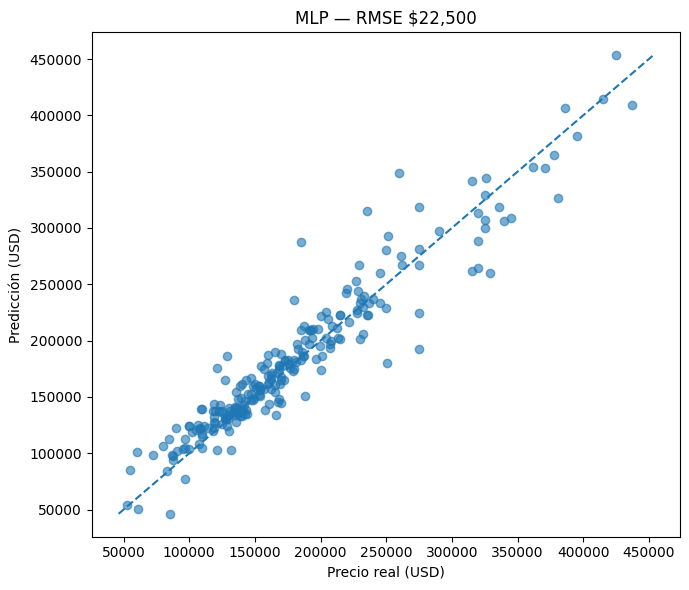

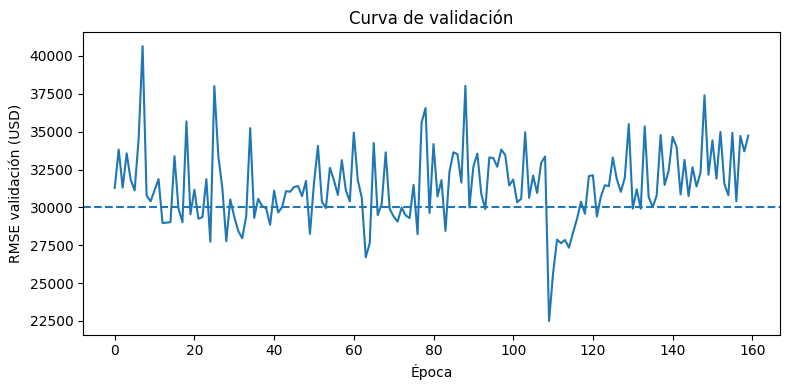

In [7]:
best_model.eval()
with torch.no_grad():
    pred_scaled=best_model(torch.tensor(X_val,dtype=torch.float32).to(device)).cpu().numpy()
pred_usd=scaled_to_usd(pred_scaled)
errors=pred_usd-y_val_usd

plt.figure(figsize=(7,6))
plt.scatter(y_val_usd,pred_usd,alpha=.6)
lo=min(y_val_usd.min(),pred_usd.min()); hi=max(y_val_usd.max(),pred_usd.max())
plt.plot([lo,hi],[lo,hi],'--')
plt.xlabel("Precio real (USD)"); plt.ylabel("Predicción (USD)")
plt.title(f"MLP — RMSE ${global_best:,.0f}"); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(best_history["val_rmse_usd"]); plt.axhline(30000,linestyle='--')
plt.xlabel("Época"); plt.ylabel("RMSE validación (USD)"); plt.title("Curva de validación")
plt.tight_layout(); plt.show()

## Guardar mejor modelo

In [8]:
os.makedirs("models",exist_ok=True); os.makedirs("reports",exist_ok=True)
torch.save({
    "model_state_dict":best_model.state_dict(),
    "architecture_name":best_arch_name,
    "hidden_layers":best_hidden,
    "hyperparams":best_hp,
    "best_epoch":best_epoch,
    "val_rmse_usd":global_best,
    "target_mean":Y_MEAN,
    "target_std":Y_STD,
    "seed":SEED,
},"models/best_mlp_v2.pt")
results_df.to_csv("reports/mlp_grid_v2.csv",index=False)
arch_df.to_csv("reports/mlp_architectures_v2.csv",index=False)
print("Guardado. RMSE final:",f"${global_best:,.2f}")

Guardado. RMSE final: $22,500.09
